<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-CongNguyen/CV-system-/blob/model-embedding/Copy_of_resume_extraction_upgraded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🤖 7. Approach 1: Sentence-BERT + Classifier (Thay thế TF-IDF + KNN)

**Lý do nâng cấp:** TF-IDF chỉ đếm từ, không hiểu ngữ nghĩa. Sentence-BERT tạo ra vector 384 chiều nắm bắt ngữ nghĩa toàn câu.

In [ ]:
print(f' Loading Sentence-BERT model: {SBERT_MODEL}...')
sbert_model = SentenceTransformer(SBERT_MODEL)

print(' Encoding resumes with Sentence-BERT...')
# Encode tất cả resume thành vectors ngữ nghĩa
sbert_embeddings = sbert_model.encode(
    df['Resume_for_bert'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f' Embeddings shape: {sbert_embeddings.shape}')
print(f'   (n_resumes={sbert_embeddings.shape[0]}, embedding_dim={sbert_embeddings.shape[1]})')

🔄 Loading Sentence-BERT model: all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🔄 Encoding resumes with Sentence-BERT...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Embeddings shape: (60, 384)
   (n_resumes=60, embedding_dim=384)


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    sbert_embeddings, df['Label'].values,
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=df['Label'].values
)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

# So sánh nhiều classifier trên SBERT embeddings
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
}

results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1_weighted': f1}
    print(f'\n📊 {name}:')
    print(f'   Accuracy:    {acc:.4f}')
    print(f'   F1 Weighted: {f1:.4f}')

# Best model
best_clf_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_clf = classifiers[best_clf_name]
print(f'\n🏆 Best classifier: {best_clf_name}')

Train size: 48, Test size: 12

📊 Logistic Regression:
   Accuracy:    1.0000
   F1 Weighted: 1.0000

📊 Linear SVM:
   Accuracy:    1.0000
   F1 Weighted: 1.0000

🏆 Best classifier: Logistic Regression


📋 Detailed Classification Report (SBERT + Best Classifier):
                precision    recall  f1-score   support

  Data Science       1.00      1.00      1.00         4
Java Developer       1.00      1.00      1.00         4
 Web Designing       1.00      1.00      1.00         4

      accuracy                           1.00        12
     macro avg       1.00      1.00      1.00        12
  weighted avg       1.00      1.00      1.00        12



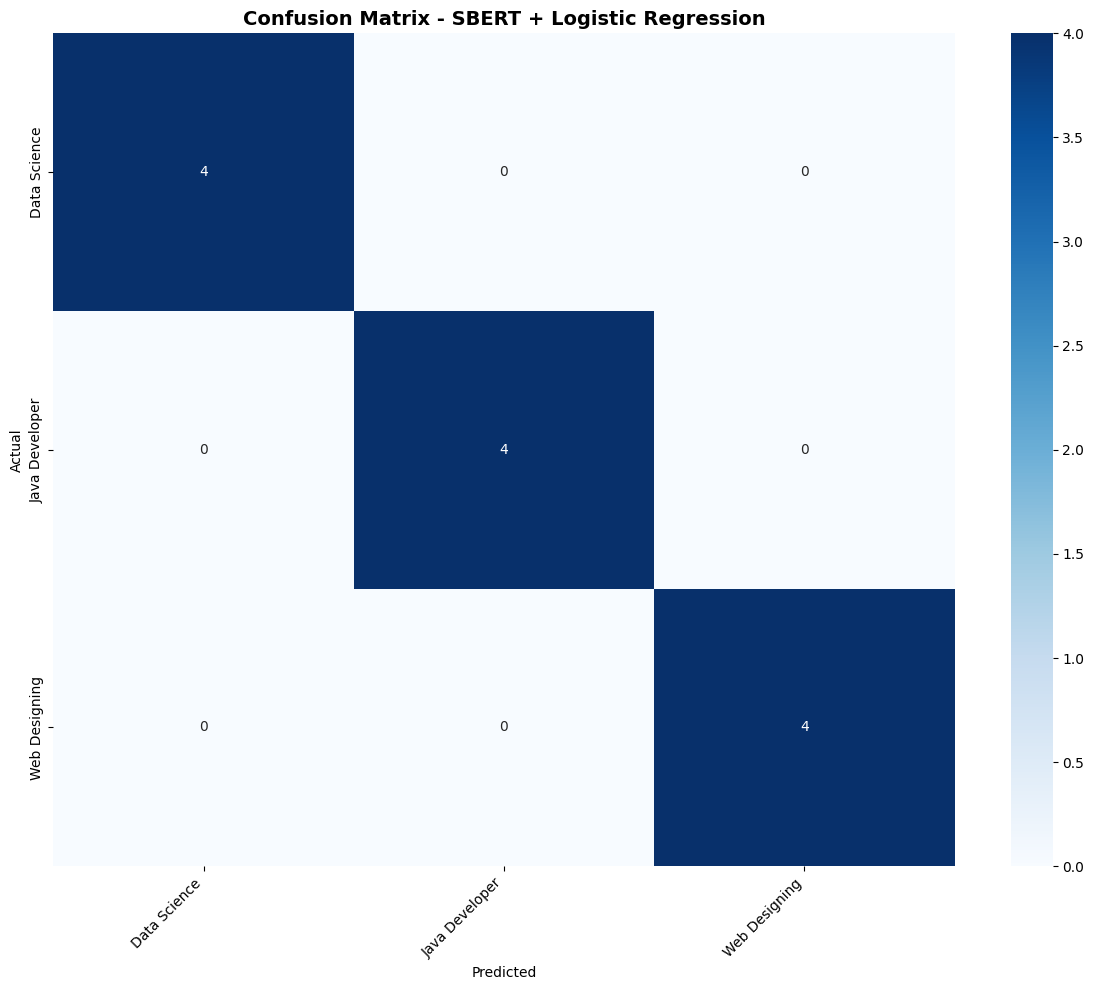

In [ ]:
# Detailed classification report
y_pred_best = best_clf.predict(X_test)
print('📋 Detailed Classification Report (SBERT + Best Classifier):')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - SBERT + {best_clf_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  8. Approach 2: BERT Fine-tuning (Thay thế LSTM)

**Lý do nâng cấp:** LSTM của bản cũ dùng random embedding và max_length=300 cắt mất ngữ cảnh. BERT đã pre-train trên 3.3 tỷ từ, hiểu ngữ cảnh hai chiều.

In [ ]:
class ResumeDataset(Dataset):
    """PyTorch Dataset cho BERT fine-tuning."""

    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(label, dtype=torch.long)
        }

In [ ]:
class BERTResumeClassifier(nn.Module):
    """BERT + Classification Head cho resume categorization."""

    def __init__(self, bert_model_name, num_classes, dropout=0.3):
        super(BERTResumeClassifier, self).__init__()
        self.bert    = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(dropout)
        hidden_size  = self.bert.config.hidden_size  # 768 for bert-base
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Dùng [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits


def train_bert_classifier(model, train_loader, val_loader, epochs=3, lr=2e-5):
    """Training loop cho BERT classifier."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs
    )

    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
    model.to(device)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # --- Validation ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                logits = model(input_ids, attention_mask)
                preds  = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = total_loss / len(train_loader)
        val_acc  = accuracy_score(all_labels, all_preds)
        val_f1   = f1_score(all_labels, all_preds, average='weighted')
        scheduler.step()

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}')

    return history


print(' BERT Classifier architecture defined!')

✅ BERT Classifier architecture defined!


In [ ]:
# Khởi tạo tokenizer và dataset
print(f' Loading BERT tokenizer: {BERT_MODEL}...')
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Train/val split
texts  = df['Resume_for_bert'].values
labels = df['Label'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    texts, labels, test_size=0.2,
    random_state=RANDOM_STATE, stratify=labels
)

train_dataset = ResumeDataset(X_tr, y_tr, tokenizer, max_len=256)
val_dataset   = ResumeDataset(X_val, y_val, tokenizer, max_len=256)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f' Datasets ready: {len(train_dataset)} train, {len(val_dataset)} val')

# Khởi tạo model
bert_clf = BERTResumeClassifier(BERT_MODEL, num_classes=num_classes)
print(f' Model parameters: {sum(p.numel() for p in bert_clf.parameters()):,}')

🔄 Loading BERT tokenizer: bert-base-uncased...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Datasets ready: 48 train, 12 val


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🤖 Model parameters: 109,679,875


In [ ]:
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import re
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

def preprocess_basic(txt):
    """Preprocessing cơ bản (giống bản cũ) - dùng cho TF-IDF / word freq."""
    txt = txt.lower()
    txt = re.sub(r'http\S+\s*', ' ', txt)
    txt = re.sub(r'[^a-zA-Z]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    tokens = nltk.word_tokenize(txt)
    stopwords = set(nltk.corpus.stopwords.words('english'))
    tokens = [w for w in tokens if w not in stopwords and len(w) > 2]
    return ' '.join(tokens)


def preprocess_for_bert(txt, max_words=400):
    """
    Preprocessing nhẹ cho BERT/Sentence-Transformer.
    BERT đã tự tokenize nên KHÔNG nên xóa stopwords.
    Chỉ clean URL, ký tự lạ và cắt bớt độ dài.
    """
    txt = re.sub(r'http\S+\s*', ' ', txt)   # remove URLs
    txt = re.sub(r'[^a-zA-Z0-9\s.,!?-]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    # Giữ tối đa max_words để tránh quá dài
    words = txt.split()[:max_words]
    return ' '.join(words)


class ResumeDataset(Dataset):
    """PyTorch Dataset cho BERT fine-tuning."""

    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(label, dtype=torch.long)
        }

class BERTResumeClassifier(nn.Module):
    """BERT + Classification Head cho resume categorization."""

    def __init__(self, bert_model_name, num_classes, dropout=0.3):
        super(BERTResumeClassifier, self).__init__()
        self.bert    = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(dropout)
        hidden_size  = self.bert.config.hidden_size  # 768 for bert-base
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Dùng [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

def train_bert_classifier(model, train_loader, val_loader, epochs=3, lr=2e-5):
    """Training loop cho BERT classifier."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs
    )

    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
    model.to(device)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # --- Validation ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                logits = model(input_ids, attention_mask)
                preds  = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = total_loss / len(train_loader)
        val_acc  = accuracy_score(all_labels, all_preds)
        val_f1   = f1_score(all_labels, all_preds, average='weighted')
        scheduler.step()

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}')

    return history

# ===== CẤU HÌNH CẦN THIẾT CHO CELL NÀY =====
BERT_MODEL  = 'bert-base-uncased'           # Cho classification
BATCH_SIZE  = 16
NUM_EPOCHS  = 3
LEARNING_RATE = 2e-5
RANDOM_STATE  = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ===========================================

# Load dataset (Kaggle: UpdatedResumeDataSet.csv hoặc Resume.csv) (moved from QPE4A7YEZgkY)
try:
    df = pd.read_csv('../input/CvsDatasets/ResumeDataSet.csv')
except FileNotFoundError:
    # Demo với dữ liệu giả nếu không có file
    print('  Dataset not found. Creating demo data...')
    demo_data = {
        'Category': ['Data Science', 'Web Designing', 'Java Developer',
                     'Data Science', 'Web Designing', 'Java Developer'] * 10,
        'Resume': [
            'Machine learning engineer with Python TensorFlow experience in deep learning neural networks',
            'Frontend developer skilled in HTML CSS JavaScript React Vue.js responsive design',
            'Java Spring Boot microservices RESTful API backend developer enterprise applications',
            'Data scientist NLP computer vision scikit-learn pandas statistical analysis',
            'UI UX designer Adobe XD Figma prototyping wireframing user interface',
            'Java developer Hibernate Maven SQL database backend systems integration'
        ] * 10
    }
    df = pd.DataFrame(demo_data)

print(f' Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f' Categories: {df["Category"].nunique()} unique classes')

# Tạo 2 phiên bản text cho các mục đích khác nhau (moved from ckTd3bRTZgka)
print(' Preprocessing resumes...')
df['Resume_clean']     = df['Resume'].apply(preprocess_basic)      # cho EDA
df['Resume_for_bert']  = df['Resume'].apply(preprocess_for_bert)   # cho BERT/SBERT

# Label encoding
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Category'])
num_classes = len(le.classes_)

print(f' Preprocessing done! {num_classes} classes encoded.')


# Khởi tạo tokenizer và dataset (moved from S-CQHovgZgkk)
print(f' Loading BERT tokenizer: {BERT_MODEL}...')
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Train/val split
texts  = df['Resume_for_bert'].values
labels = df['Label'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    texts, labels, test_size=0.2,
    random_state=RANDOM_STATE, stratify=labels
)

train_dataset = ResumeDataset(X_tr, y_tr, tokenizer, max_len=256)
val_dataset   = ResumeDataset(X_val, y_val, tokenizer, max_len=256)🤖 7. Approach 1: Sentence-BERT + Classifier (Thay thế TF-IDF + KNN)
Lý do nâng cấp: TF-IDF chỉ đếm từ, không hiểu ngữ nghĩa. Sentence-BERT tạo ra vector 384 chiều nắm bắt ngữ nghĩa toàn câu.


[ ]
print(f' Loading Sentence-BERT model: {SBERT_MODEL\}...')
sbert_model = SentenceTransformer(SBERT_MODEL)

print(' Encoding resumes with Sentence-BERT...')
# Encode tất cả resume thành vectors ngữ nghĩa
sbert_embeddings = sbert_model.encode(
    df['Resume_for_bert'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f' Embeddings shape: {sbert_embeddings.shape\}')
print(f'   (n_resumes={sbert_embeddings.shape[0]\}, embedding_dim={sbert_embeddings.shape[1]\})')


[ ]
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    sbert_embeddings, df['Label'].values,
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=df['Label'].values
)

print(f'Train size: {X_train.shape[0]\}, Test size: {X_test.shape[0]\}')

# So sánh nhiều classifier trên SBERT embeddings
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
\}

results = {\}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1_weighted': f1\}
    print(f'\\n📊 {name\}:')
    print(f'   Accuracy:    {acc:.4f\}')
    print(f'   F1 Weighted: {f1:.4f\}')

# Best model
best_clf_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_clf = classifiers[best_clf_name]
print(f'\\n🏆 Best classifier: {best_clf_name\}')
Train size: 48, Test size: 12

📊 Logistic Regression:
   Accuracy:    1.0000
   F1 Weighted: 1.0000

📊 Linear SVM:
   Accuracy:    1.0000
   F1 Weighted: 1.0000

🏆 Best classifier: Logistic Regression

[ ]
# Detailed classification report
y_pred_best = best_clf.predict(X_test)
print('📋 Detailed Classification Report (SBERT + Best Classifier):')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - SBERT + {best_clf_name\}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

8. Approach 2: BERT Fine-tuning (Thay thế LSTM)
Lý do nâng cấp: LSTM của bản cũ dùng random embedding và max_length=300 cắt mất ngữ cảnh. BERT đã pre-train trên 3.3 tỷ từ, hiểu ngữ cảnh hai chiều.


[ ]
class ResumeDataset(Dataset):
    """PyTorch Dataset cho BERT fine-tuning."""

    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts    = texts
        self.labels   = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(label, dtype=torch.long)
        \}

[ ]
class BERTResumeClassifier(nn.Module):
    """BERT + Classification Head cho resume categorization."""

    def __init__(self, bert_model_name, num_classes, dropout=0.3):
        super(BERTResumeClassifier, self).__init__()
        self.bert    = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(dropout)
        hidden_size  = self.bert.config.hidden_size  # 768 for bert-base
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Dùng [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits


def train_bert_classifier(model, train_loader, val_loader, epochs=3, lr=2e-5):
    """Training loop cho BERT classifier."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs
    )

    history = {'train_loss': [], 'val_acc': [], 'val_f1': []\}
    model.to(device)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # --- Validation ---
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                logits = model(input_ids, attention_mask)
                preds  = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = total_loss / len(train_loader)
        val_acc  = accuracy_score(all_labels, all_preds)
        val_f1   = f1_score(all_labels, all_preds, average='weighted')
        scheduler.step()

        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Epoch {epoch+1\}/{epochs\} | Loss: {avg_loss:.4f\} | Val Acc: {val_acc:.4f\} | Val F1: {val_f1:.4f\}')

    return history


print(' BERT Classifier architecture defined!')
✅ BERT Classifier architecture defined!

[ ]
# Khởi tạo tokenizer và dataset
print(f' Loading BERT tokenizer: {BERT_MODEL\}...')
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Train/val split
texts  = df['Resume_for_bert'].values
labels = df['Label'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    texts, labels, test_size=0.2,
    random_state=RANDOM_STATE, stratify=labels
)

train_dataset = ResumeDataset(X_tr, y_tr, tokenizer, max_len=256)
val_dataset   = ResumeDataset(X_val, y_val, tokenizer, max_len=256)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f' Datasets ready: {len(train_dataset)\} train, {len(val_dataset)\} val')

# Khởi tạo model
bert_clf = BERTResumeClassifier(BERT_MODEL, num_classes=num_classes)
print(f' Model parameters: {sum(p.numel() for p in bert_clf.parameters()):,\}')


[ ]
$0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f' Datasets ready: {len(train_dataset)} train, {len(val_dataset)} val')

# Khởi tạo model
bert_clf = BERTResumeClassifier(BERT_MODEL, num_classes=num_classes)
print(f' Model parameters: {sum(p.numel() for p in bert_clf.parameters()):,}')

# Train BERT (comment out nếu không có GPU để tiết kiệm thời gian)
print(' Training BERT Classifier...')
print(' Tip: Sử dụng GPU để tăng tốc độ training!')

bert_history = train_bert_classifier(
    bert_clf, train_loader, val_loader,
    epochs=NUM_EPOCHS, lr=LEARNING_RATE
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(bert_history['train_loss'], 'b-o', label='Train Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(bert_history['val_acc'], 'g-o', label='Val Accuracy')
axes[1].plot(bert_history['val_f1'],  'r-s', label='Val F1')
axes[1].set_title('Validation Metrics', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

⚠️  Dataset not found. Creating demo data...
📊 Dataset loaded: 60 rows, 2 columns
📁 Categories: 3 unique classes
🔄 Preprocessing resumes...
✅ Preprocessing done! 3 classes encoded.
🔄 Loading BERT tokenizer: bert-base-uncased...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Datasets ready: 48 train, 12 val


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🤖 Model parameters: 109,679,875
🚀 Training BERT Classifier...
💡 Tip: Sử dụng GPU để tăng tốc độ training!
Epoch 1/3 | Loss: 1.0733 | Val Acc: 0.5833 | Val F1: 0.5481
